<a href="https://colab.research.google.com/github/mariangelesalomar-sudo/eigenfaces-dma-grupo-1/blob/main/eigenfaces_caras_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento facial con Eigenfaces (PCA)

**Maestría en Ciencia de Datos — Data Mining Avanzado — 2026 / 2° Cuatrimestre**

Trabajo grupal: detección y comparación de las caras de 14 alumnos de la clase usando
el método clásico de **Eigenfaces** (Análisis de Componentes Principales).

## Pipeline
1. Carga de fotos desde Google Drive (formatos `.jpg`, `.jpeg`, `.png`, `.heic`)
2. Detección de rostros con **DeepFace (RetinaFace)**, con respaldo en Haar Cascade
3. Recorte por borde oval del rostro y conversión a escala de grises de 30×30 px
4. Reducción de dimensionalidad con PCA → Eigenfaces
5. Cálculo del vector promedio por alumno
6. Matriz de distancias euclidianas entre alumnos
7. Ranking de pares más parecidos / menos parecidos

## Notas importantes
- Las fotos **no** se incluyen en este repositorio por privacidad. Cada integrante del grupo
  debe tener acceso a la carpeta compartida de Google Drive.
- El notebook está pensado para correr en **Google Colab**.


## **Paso previo** : Definicion de tamano de cara que correra cada integrante para probar como funciona la red neuronal

In [1]:
# Montar Drive primero, antes de definir rutas
from google.colab import drive
drive.mount('/content/drive')


TAMANO = 30   # ← CADA INTEGRANTE CAMBIA SOLO ESTE NÚMERO
              #   Integrante 1: 30 Mariangeles
              #   Integrante 2: 50 Judith
              #   Integrante 3: 80 Juani
              #   Integrante 4: 100 Fede

# Todo lo demás se calcula solo
DIMENSIONES   = TAMANO * TAMANO
NOMBRE_CONFIG = f"{TAMANO}x{TAMANO}"

RUTA_BASE       = '/content/drive/MyDrive/DMA'
ruta_datos      = f'{RUTA_BASE}/datos_{NOMBRE_CONFIG}'
ruta_checkpoint = f'{ruta_datos}/checkpoint.npz'

import os
os.makedirs(ruta_datos, exist_ok=True)

print("=" * 45)
print(f"⚙️  CONFIGURACIÓN ACTIVA")
print("=" * 45)
print(f"   Tamaño:      {TAMANO}×{TAMANO} píxeles")
print(f"   Dimensiones: {DIMENSIONES:,} por cara")
print(f"   Carpeta:     datos_{NOMBRE_CONFIG}/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚙️  CONFIGURACIÓN ACTIVA
   Tamaño:      30×30 píxeles
   Dimensiones: 900 por cara
   Carpeta:     datos_30x30/


## 1. Instalar librerías externas





In [2]:
# opencv-python-headless → detectar y recortar caras
# scikit-learn           → hacer PCA (Eigenfaces)
# pillow-heif            → leer fotos .HEIC de iPhone
# matplotlib             → hacer gráficos
# scipy                  → calcular distancias entre vectores

!pip install opencv-python-headless scikit-learn pillow-heif matplotlib scipy Pillow --quiet

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


## 2. Importar librerías al entorno de trabajo

In [3]:
import os                          # para leer archivos del disco
import cv2                         # para procesar imágenes y detectar caras
import numpy as np                 # para trabajar con vectores y matrices
import matplotlib.pyplot as plt    # para hacer gráficos y mostrar imágenes
from PIL import Image              # para abrir imágenes (incluyendo HEIC)
from sklearn.decomposition import PCA      # para hacer Eigenfaces
from scipy.spatial.distance import euclidean  # para calcular distancias
from google.colab import drive     # para conectarse a Google Drive

# Activar soporte para fotos .HEIC (formato iPhone)
from pillow_heif import register_heif_opener
register_heif_opener()

import warnings
warnings.filterwarnings('ignore')  # silenciar advertencias menores

print("✅ Todo importado. Estamos listos para trabajar.")

✅ Todo importado. Estamos listos para trabajar.


## 3. Conectar a Google Drive

In [4]:
ruta_fotos = '/content/drive/MyDrive/caras'

archivos_totales = os.listdir(ruta_fotos)

print(f"Drive conectado correctamente")
print(f"Carpeta: {ruta_fotos}")
print(f"Cantidad total de archivos en la carpeta: {len(archivos_totales)}")

Drive conectado correctamente
Carpeta: /content/drive/MyDrive/caras
Cantidad total de archivos en la carpeta: 2225


## 4. Definir a qué alumno pertenece cada foto

In [5]:
# PROBLEMA: todas las fotos están en una sola carpeta,
# y el nombre del alumno está dentro del nombre del archivo.
# Además, el mismo alumno aparece escrito de formas distintas
# (typos, mayúsculas, guiones extra, etc.)

MAPA_NOMBRES = {
    # Juani (4 variantes)
    'juani_cahionne'    : 'juani_cacchione',
    'juani_cachionne'   : 'juani_cacchione',
    'juani_cachione'    : 'juani_cacchione',
    'juani_cacchione'   : 'juani_cacchione',
    'juan_cacchione'    : 'juani_cacchione',
    # Juani P (2 variantes)
    'juani_paberolis'   : 'juani_paberolis',
    'ignacio_paberolis' : 'juani_paberolis',

    # Mariángeles (2 variantes)
    'mariangeles_alomar': 'mariangeles_alomar',
    'mariangeles_aloar' : 'mariangeles_alomar',
    # Miguel (2 variantes)
    'miguel_garrone'    : 'miguel_garrone',
    'migue_garrone'     : 'miguel_garrone',
    # El resto (sin variantes)
    'agustina_sebben'   : 'agustina_sebben',
    'belen_maldonado'   : 'belen_maldonado',
    'fede_spinelli'     : 'fede_spinelli',
    'guillermo_anso'    : 'guillermo_anso',
    'judi_luna'         : 'judi_luna',
    'judi_luna_'        : 'judi_luna',

    'lucia_tamplin'     : 'lucia_tamplin',
    'Lucia_Tamplin'     : 'lucia_tamplin',
    'martin_ceriotti'   : 'martin_ceriotti',
    'matias_villanueva' : 'matias_villanueva',
    'millie_teran'      : 'millie_teran',
    'tomas_delbo'       : 'tomas_delbo',
}

def extraer_nombre_alumno(nombre_archivo):
    """Dado el nombre de un archivo, devuelve el nombre canónico del alumno."""
    sin_extension = os.path.splitext(nombre_archivo)[0]
    # Recorremos los prefijos del más largo al más corto
    prefijos = sorted(MAPA_NOMBRES.keys(), key=len, reverse=True)
    for prefijo in prefijos:
        if sin_extension.startswith(prefijo):
            return MAPA_NOMBRES[prefijo]
    return None  # archivo no reconocido

# ── Prueba visual ──────────────────────────────────────────
print("Probando la función con algunos ejemplos:\n")
ejemplos = [
    'martin_ceriotti (5).jpg',
    'belen_maldonado_001.heic',
    'juani_cahionne (3).jpeg',
    'juani_cacchione (1).heic',
    'migue_garrone (1).MOV',
    'Lucia_Tamplin_03.jpeg',
    'judi_luna_ (2).jpg',
]
for e in ejemplos:
    resultado = extraer_nombre_alumno(e)
    print(f"   '{e}'  →  '{resultado}'")

print("\nLa función reconoce correctamente los nombres")

Probando la función con algunos ejemplos:

   'martin_ceriotti (5).jpg'  →  'martin_ceriotti'
   'belen_maldonado_001.heic'  →  'belen_maldonado'
   'juani_cahionne (3).jpeg'  →  'juani_cacchione'
   'juani_cacchione (1).heic'  →  'juani_cacchione'
   'migue_garrone (1).MOV'  →  'miguel_garrone'
   'Lucia_Tamplin_03.jpeg'  →  'lucia_tamplin'
   'judi_luna_ (2).jpg'  →  'judi_luna'

La función reconoce correctamente los nombres


4.1 Control de nombres mapeados

In [6]:
# ── Verificación automática: ninguna foto sin mapear ────────
extensiones = ('.jpg', '.jpeg', '.png', '.heic')
no_reconocidos = []
reconocidos    = {}

for archivo in sorted(os.listdir(ruta_fotos)):
    ext = os.path.splitext(archivo)[1].lower()
    if ext not in extensiones:
        continue
    alumno = extraer_nombre_alumno(archivo)
    if alumno is None:
        no_reconocidos.append(archivo)
    else:
        reconocidos[alumno] = reconocidos.get(alumno, 0) + 1

print(f"\n📊 COBERTURA DEL MAPA DE NOMBRES")
print(f"{'='*50}")
print(f"   ✅ Fotos reconocidas:  {sum(reconocidos.values())}")
print(f"   ❌ No reconocidas:     {len(no_reconocidos)}")

print(f"\n   Fotos por alumno:")
for alumno, cantidad in sorted(reconocidos.items()):
    print(f"   {alumno:25s}: {cantidad:4d} fotos")

if no_reconocidos:
    print(f"\n⚠️  ATENCIÓN — estos archivos NO van a procesarse:")
    for f in no_reconocidos:
        print(f"   {f}")
    print(f"\n   → Agregá los prefijos faltantes al MAPA_NOMBRES y volvé a correr esta celda.")
else:
    print(f"\n✅ Todas las fotos están mapeadas. Podés continuar con la Celda 5.")


📊 COBERTURA DEL MAPA DE NOMBRES
   ✅ Fotos reconocidas:  2223
   ❌ No reconocidas:     0

   Fotos por alumno:
   agustina_sebben          :  119 fotos
   belen_maldonado          :  113 fotos
   fede_spinelli            :  125 fotos
   guillermo_anso           :  155 fotos
   juani_cacchione          :  140 fotos
   juani_paberolis          :   93 fotos
   judi_luna                :  302 fotos
   lucia_tamplin            :  137 fotos
   mariangeles_alomar       :  139 fotos
   martin_ceriotti          :  198 fotos
   matias_villanueva        :  176 fotos
   miguel_garrone           :  163 fotos
   millie_teran             :  220 fotos
   tomas_delbo              :  143 fotos

✅ Todas las fotos están mapeadas. Podés continuar con la Celda 5.


## 5. Abrir y mostrar UNA foto original

Foto original de martin_ceriotti: 'martin_ceriotti (1).heic'
   Dimensiones: 2268 px de ancho × 4032 px de alto
   Canales de color: 3 (R, G, B)


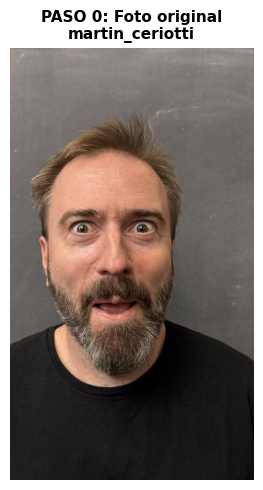

In [7]:
# Antes de procesar todo, vamos a ver cómo se ve una foto
# tal cual sale de la cámara, sin ninguna modificación.

alumno_ejemplo = 'martin_ceriotti'

foto_ejemplo = None
for archivo in sorted(os.listdir(ruta_fotos)):
    if extraer_nombre_alumno(archivo) == alumno_ejemplo:
        ext = os.path.splitext(archivo)[1].lower()
        if ext in ('.jpg', '.jpeg', '.png', '.heic'):
            foto_ejemplo = archivo
            break

ruta_ejemplo = os.path.join(ruta_fotos, foto_ejemplo)

# Leer la imagen (soporte para HEIC y formatos comunes)
def leer_imagen(ruta):
    ext = os.path.splitext(ruta)[1].lower()
    if ext == '.heic':
        img_pil = Image.open(ruta).convert('RGB')
        return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    else:
        return cv2.imread(ruta)

imagen_original = leer_imagen(ruta_ejemplo)
imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

print(f"Foto original de {alumno_ejemplo}: '{foto_ejemplo}'")
print(f"   Dimensiones: {imagen_original.shape[1]} px de ancho × {imagen_original.shape[0]} px de alto")
print(f"   Canales de color: {imagen_original.shape[2]} (R, G, B)")

plt.figure(figsize=(4, 5))
plt.imshow(imagen_rgb)
plt.title(f"PASO 0: Foto original\n{alumno_ejemplo}", fontsize=11, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Recorte por borde real del rostro con DeepFace

In [8]:
# DeepFace detecta la cara Y sus landmarks (puntos clave).
# Con esos puntos podemos dibujar una MÁSCARA ELÍPTICA que sigue el óvalo
# de la cara y recortar SOLO lo que está dentro del óvalo (fondo negro afuera).

!pip install deepface --quiet
print("✅ DeepFace instalado")

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace

print("✅ DeepFace importado\n")


def recortar_cara_por_borde(imagen_bgr, margen=0.18):
    """
    Detecta la cara con DeepFace y recorta siguiendo el borde
    real del rostro (forma elíptica), no un rectángulo rígido.
    """
    alto, ancho = imagen_bgr.shape[:2]
    imagen_rgb  = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    try:
        caras = DeepFace.extract_faces(
            img_path          = imagen_bgr,
            detector_backend  = 'opencv',
            enforce_detection = False,
            align             = True
        )

        caras_validas = [c for c in caras if c['confidence'] > 0]
        if not caras_validas:
            return None, None, None

        mejor     = max(caras_validas, key=lambda c: c['confidence'])
        confianza = mejor['confidence']

        region = mejor['facial_area']
        x, y   = region['x'], region['y']
        w, h   = region['w'], region['h']

        landmarks = region
        ojo_izq   = landmarks.get('left_eye')
        ojo_der   = landmarks.get('right_eye')
        nariz     = landmarks.get('nose')
        boca_izq  = landmarks.get('mouth_left')
        boca_der  = landmarks.get('mouth_right')

        # Centro: punto medio entre los dos ojos
        if ojo_izq and ojo_der:
            cx = int((ojo_izq[0] + ojo_der[0]) / 2)
            cy = int((ojo_izq[1] + ojo_der[1]) / 2)
        else:
            cx = x + w // 2
            cy = y + h // 2

        # Eje horizontal: distancia entre ojos × factor de margen
        if ojo_izq and ojo_der:
            dist_ojos  = np.sqrt((ojo_der[0]-ojo_izq[0])**2 +
                                 (ojo_der[1]-ojo_izq[1])**2)
            radio_x    = int(dist_ojos * 1.5 * (1 + margen))
        else:
            radio_x    = int(w * 0.55 * (1 + margen))

        # Eje vertical
        if ojo_izq and ojo_der and boca_izq and boca_der:
            cy_boca    = int((boca_izq[1] + boca_der[1]) / 2)
            dist_ojo_boca = abs(cy_boca - cy)
            radio_y_abajo  = int(dist_ojo_boca * 1.3 * (1 + margen))
            radio_y_arriba = int(dist_ojo_boca * 1.6 * (1 + margen))
        else:
            radio_y_abajo  = int(h * 0.55 * (1 + margen))
            radio_y_arriba = int(h * 0.55 * (1 + margen))

        # Ángulo de inclinación de la cara
        if ojo_izq and ojo_der:
            angulo = np.degrees(np.arctan2(
                ojo_der[1] - ojo_izq[1],
                ojo_der[0] - ojo_izq[0]
            ))
        else:
            angulo = 0

        # Recorte rectangular amplio (zona de trabajo)
        margen_rect = int(max(radio_x, radio_y_abajo, radio_y_arriba) * 1.1)
        rx1 = max(0,     cx - margen_rect)
        ry1 = max(0,     cy - margen_rect)
        rx2 = min(ancho, cx + margen_rect)
        ry2 = min(alto,  cy + margen_rect)

        recorte_rgb = imagen_rgb[ry1:ry2, rx1:rx2].copy()
        rh, rw      = recorte_rgb.shape[:2]

        cx_local = cx - rx1
        cy_local = cy - ry1

        radio_y_prom = (radio_y_arriba + radio_y_abajo) // 2

        mascara = np.zeros((rh, rw), dtype=np.uint8)
        cv2.ellipse(
            mascara,
            center    = (cx_local, cy_local),
            axes      = (radio_x, radio_y_prom),
            angle     = angulo,
            startAngle= 0,
            endAngle  = 360,
            color     = 255,
            thickness = -1
        )

        mascara_suave = cv2.GaussianBlur(mascara, (21, 21), 0)
        mascara_3ch = np.stack([mascara_suave]*3, axis=-1).astype(np.float32) / 255.0
        cara_con_mascara = (recorte_rgb.astype(np.float32) * mascara_3ch).astype(np.uint8)

        ys, xs = np.where(mascara > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None, None, None

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        cara_recortada = cara_con_mascara[y_min:y_max, x_min:x_max]

        cara_gris       = cv2.cvtColor(cara_recortada, cv2.COLOR_RGB2GRAY)
        cara_gris_tamano = cv2.resize(cara_gris, (TAMANO, TAMANO))

        return cara_gris_tamano, cara_recortada, confianza

    except Exception as e:
        return None, None, None


# Haar como respaldo
clasificador_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

✅ DeepFace instalado
✅ DeepFace importado



## 7. Procesar TODAS las fotos (con checkpoint)

In [ ]:
## 7. Procesar TODAS las fotos (con checkpoint)

# MEJORAS clave:
#   1. BARRA DE PROGRESO
#   2. SIN DEDUPLICACIÓN: se procesan TODAS las fotos aunque tengan el mismo nombre base
#   3. GUARDADO PARCIAL cada 50 fotos (checkpoint en Drive)
#   4. RETOMAR DESDE CHECKPOINT si Colab se reinicia — nunca se pierde trabajo
#   5. DeepFace + Haar como respaldo

import numpy as np
import os
import cv2
import time
from PIL import Image

EXTENSIONES     = ('.jpg', '.jpeg', '.png', '.heic')
GUARDAR_CADA    = 50
ruta_checkpoint = f'{ruta_datos}/checkpoint.npz'

def leer_imagen(ruta):
    ext = os.path.splitext(ruta)[1].lower()
    if ext == '.heic':
        try:
            img_pil = Image.open(ruta).convert('RGB')
            return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        except:
            return None
    else:
        return cv2.imread(ruta)

clasificador_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# ── Construir lista de archivos a procesar ──────────────────
# Sin deduplicación: se toman TODAS las imágenes reconocidas
print("📋 Analizando archivos disponibles...\n")

archivos_todos      = sorted(os.listdir(ruta_fotos))
archivos_a_procesar = []

for archivo in archivos_todos:
    ext = os.path.splitext(archivo)[1].lower()
    if ext not in EXTENSIONES:
        continue
    alumno = extraer_nombre_alumno(archivo)
    if alumno is None:
        continue
    archivos_a_procesar.append(archivo)

archivos_a_procesar = sorted(archivos_a_procesar)
print(f"   Total de fotos a procesar: {len(archivos_a_procesar)}")

# ── Inicializar variables ────────────────────────────────────
todos_vectores         = []
todas_etiquetas        = []
todas_imagenes         = []
imagen_repr            = {}
ruta_repr              = {}
conteo                 = {}
archivos_ya_procesados = set()

os.makedirs(os.path.dirname(ruta_checkpoint), exist_ok=True)

# ── Retomar desde checkpoint si existe ───────────────────────
if os.path.exists(ruta_checkpoint):
    print(f"\n♻️  Checkpoint encontrado. Retomando desde donde quedó...")
    cp = np.load(ruta_checkpoint, allow_pickle=True)
    todos_vectores         = list(cp['vectores'])
    todas_etiquetas        = list(cp['etiquetas'])
    archivos_ya_procesados = set(cp['archivos_procesados'])

    for v, e in zip(todos_vectores, todas_etiquetas):
        conteo[e] = conteo.get(e, 0) + 1
        if e not in imagen_repr:
            imagen_repr[e] = v.reshape(TAMANO, TAMANO).astype(np.uint8)

    todas_imagenes = [v.reshape(TAMANO, TAMANO).astype(np.uint8)
                      for v in todos_vectores]

    print(f"   ✅ {len(todos_vectores)} fotos recuperadas")
    print(f"   ⏭️  Se saltean {len(archivos_ya_procesados)} archivos ya procesados\n")
else:
    print(f"\n🆕 No hay checkpoint previo. Empezando desde cero.\n")

# ── Procesar solo los pendientes ─────────────────────────────
archivos_pendientes = [a for a in archivos_a_procesar
                       if a not in archivos_ya_procesados]

total       = len(archivos_pendientes)
sin_cara    = 0
errores     = 0
uso_haar    = 0
inicio      = time.time()

print(f"🔍 Procesando {total} archivos pendientes...\n")

for i, archivo in enumerate(archivos_pendientes):
    if i % 10 == 0 or i == total - 1:
        pct      = (i + 1) / total
        barras   = int(pct * 30)
        barra    = "█" * barras + "░" * (30 - barras)
        elapsed  = time.time() - inicio
        restante = (elapsed / (i + 1)) * (total - i - 1) if i > 0 else 0
        print(f"\r   [{barra}] {i+1}/{total}  "
              f"({pct*100:.0f}%)  ~{restante/60:.1f} min restantes",
              end='', flush=True)

    alumno = extraer_nombre_alumno(archivo)
    ruta   = os.path.join(ruta_fotos, archivo)
    imagen = leer_imagen(ruta)
    if imagen is None:
        errores += 1
        archivos_ya_procesados.add(archivo)
        continue

    cara_tamano, _, _ = recortar_cara_por_borde(imagen)

    if cara_tamano is None:
        gris  = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
        caras = clasificador_haar.detectMultiScale(
            gris, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
        )
        if len(caras) > 0:
            x, y, w, h = sorted(caras, key=lambda c: c[2]*c[3], reverse=True)[0]
            cara_tamano = cv2.resize(gris[y:y+h, x:x+w], (TAMANO, TAMANO))
            uso_haar   += 1
        else:
            sin_cara += 1
            archivos_ya_procesados.add(archivo)
            continue

    vector = cara_tamano.flatten().astype(float)
    todos_vectores.append(vector)
    todas_etiquetas.append(alumno)
    todas_imagenes.append(cara_tamano)
    conteo[alumno] = conteo.get(alumno, 0) + 1
    archivos_ya_procesados.add(archivo)

    if alumno not in imagen_repr:
        imagen_repr[alumno] = cara_tamano
        ruta_repr[alumno]   = ruta

    if len(todos_vectores) % GUARDAR_CADA == 0:
        np.savez_compressed(
            ruta_checkpoint,
            vectores            = np.array(todos_vectores),
            etiquetas           = np.array(todas_etiquetas),
            archivos_procesados = np.array(list(archivos_ya_procesados))
        )

np.savez_compressed(
    ruta_checkpoint,
    vectores            = np.array(todos_vectores),
    etiquetas           = np.array(todas_etiquetas),
    archivos_procesados = np.array(list(archivos_ya_procesados))
)

matriz_vectores = np.array(todos_vectores)
etiquetas       = np.array(todas_etiquetas)
nombres_alumnos = sorted(conteo.keys())

print(f"\n\n📊 RESUMEN: {len(todos_vectores)} fotos procesadas")
print(f"   Sin cara: {sin_cara}  |  Errores: {errores}  |  Haar respaldo: {uso_haar}")

📋 Analizando archivos disponibles...

   Total de fotos a procesar: 2223
🔍 Procesando 2223 archivos pendientes...

   [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 101/2223  (5%)  ~433.8 min restantes

## 8. PCA — Eigenfaces

In [ ]:
# Reducimos las dimensiones a eigenfaces (componentes principales).

N_EIGENFACES = 80 # todos los integrantes usan 80 eigenfaces
n_componentes = min(len(todos_vectores) - 1, N_EIGENFACES)

print(f"Aplicando PCA: {len(todos_vectores)} fotos × {DIMENSIONES:,} dimensiones → {n_componentes} eigenfaces\n")

pca = PCA(n_components=n_componentes, whiten=True)
pca.fit(matriz_vectores)

fotos_proyectadas = pca.transform(matriz_vectores)

varianza = np.cumsum(pca.explained_variance_ratio_) * 100
print(f"✅ Con {n_componentes} eigenfaces capturamos el {varianza[-1]:.1f}% de la información")

# ── Cuántos eigenfaces necesitaría para 90% y 95% de varianza ──
# (útil para comparar en la presentación grupal)
for pct_objetivo in [90, 95]:
    idx = np.argmax(varianza >= pct_objetivo) + 1
    print(f"   Para llegar al {pct_objetivo}% de varianza hacen falta: {idx} eigenfaces")

# 8.b Cara Promedio

In [ ]:
# ── CELDA 8b: Cara promedio ──────────────────────────────────
# La "cara promedio" es el promedio de todos los vectores
# de píxeles ANTES de aplicar PCA.
# Visualmente muestra cómo es la cara "típica" del grupo.

cara_promedio = matriz_vectores.mean(axis=0).reshape(TAMANO, TAMANO)

plt.figure(figsize=(3, 3))
plt.imshow(cara_promedio, cmap='gray', interpolation='nearest')
plt.title(f'Cara promedio del grupo\n({TAMANO}×{TAMANO} px)', fontsize=10, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/cara_promedio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: cara_promedio.png")

# **8.c Matriz de Eigenfaces**

In [ ]:
# ── CELDA 8c: Matriz de Eigenfaces ───────────────────────────
# Cada eigenface es un patrón de variación entre todas las caras.
# El primero captura la mayor diferencia, el segundo la segunda mayor, etc.
# Se ven como "caras fantasma" porque son combinaciones de rasgos.

n_mostrar = min(80, n_componentes)   # mostrar todos los 80 eigenfaces
cols      = 10
filas     = n_mostrar // cols

fig, axes = plt.subplots(filas, cols, figsize=(cols * 2, filas * 2.2))
axes      = axes.flatten()

for i in range(n_mostrar):
    ef = pca.components_[i].reshape(TAMANO, TAMANO)
    axes[i].imshow(ef, cmap='gray')
    axes[i].set_title(f'EF {i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)',
                      fontsize=6)
    axes[i].axis('off')

plt.suptitle(f'Los {n_mostrar} Eigenfaces — {NOMBRE_CONFIG}\n'
             f'(varianza total capturada: {varianza[n_mostrar-1]:.1f}%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/matriz_eigenfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: matriz_eigenfaces.png")
print(f"\n💡 Interpretación:")
print(f"   EF 1 explica el {pca.explained_variance_ratio_[0]*100:.1f}% de la varianza total")
print(f"   EF 2 explica el {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   Los primeros eigenfaces suelen capturar iluminación y orientación general")
print(f"   Los últimos capturan detalles más finos que diferencian personas específicas")

## 9. Vector promedio por alumno y matriz de distancias

In [ ]:
# Cada alumno tiene varias fotos. Calculamos el PROMEDIO de sus vectores
# para representarlo con UN solo punto en el espacio de eigenfaces.

vectores_promedio = {}
for nombre in nombres_alumnos:
    indices = [i for i, e in enumerate(etiquetas) if e == nombre]
    proyecciones = fotos_proyectadas[indices]
    vectores_promedio[nombre] = proyecciones.mean(axis=0)

# Matriz de distancias euclidianas
n = len(nombres_alumnos)
matriz_dist = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            matriz_dist[i][j] = euclidean(
                vectores_promedio[nombres_alumnos[i]],
                vectores_promedio[nombres_alumnos[j]]
            )

print("✅ Matriz de distancias calculada")

## 10. Resultado final — Ranking de similitud

In [ ]:
print("=" * 65)
print("🏆 RANKING DE SIMILITUD")
print("=" * 65)

pares = []
for i in range(n):
    for j in range(i + 1, n):
        pares.append({
            'a1': nombres_alumnos[i],
            'a2': nombres_alumnos[j],
            'd' : matriz_dist[i][j]
        })

pares_ord = sorted(pares, key=lambda x: x['d'])

print("\n🥇 Los 5 pares MÁS PARECIDOS:")
for k, p in enumerate(pares_ord[:5], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n💨 Los 5 pares MENOS PARECIDOS:")
for k, p in enumerate(pares_ord[-5:][::-1], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n👯 CARA GEMELA de cada alumno:")
for i, nombre in enumerate(nombres_alumnos):
    opciones = [(nombres_alumnos[j], matriz_dist[i][j]) for j in range(n) if j != i]
    gemelo, dist = min(opciones, key=lambda x: x[1])
    print(f"   {nombre:25s} → {gemelo:25s}  (dist: {dist:.2f})")

# 11. Guardar en Drive

In [ ]:
import json
import numpy as np

print(f"💾 Guardando datos {NOMBRE_CONFIG} en Drive...\n")

np.save(f'{ruta_datos}/matriz_vectores.npy', matriz_vectores)
np.save(f'{ruta_datos}/etiquetas.npy', etiquetas)
np.savez(f'{ruta_datos}/imagenes_repr.npz', **imagen_repr)

with open(f'{ruta_datos}/conteo.txt', 'w') as f:
    for nombre, cantidad in conteo.items():
        f.write(f'{nombre},{cantidad}\n')

with open(f'{ruta_datos}/rutas_repr.json', 'w') as f:
    json.dump(ruta_repr, f, indent=2)

# Guardar configuración para saber qué tamaño usó este integrante
with open(f'{ruta_datos}/configuracion.txt', 'w') as f:
    f.write(f'tamano={TAMANO}\n')
    f.write(f'dimensiones={DIMENSIONES}\n')
    f.write(f'fotos_procesadas={len(todos_vectores)}\n')
    f.write(f'alumnos={len(nombres_alumnos)}\n')

print(f"✅ Guardado en: datos_{NOMBRE_CONFIG}/")
for archivo in sorted(os.listdir(ruta_datos)):
    tam = os.path.getsize(f'{ruta_datos}/{archivo}') / 1024
    print(f"   📄 {archivo:35s} ({tam:.0f} KB)")